Executing Phase 22 Multi-Class FDI (FDI1-FDI7) on: cuda
Input arrays loaded. X_train: (5011, 30, 12), X_test: (1052, 30, 12)

--- Multiclass Distribution (Train Split) ---
  Normal (Class 0)    : 3430 windows (68.45%)
  FDI1                :  226 windows (4.51%)
  FDI2                :  226 windows (4.51%)
  FDI3                :  226 windows (4.51%)
  FDI4                :  226 windows (4.51%)
  FDI5                :  226 windows (4.51%)
  FDI6                :  226 windows (4.51%)
  FDI7                :  225 windows (4.49%)
[SUCCESS] Loaded Pretrained SSL Encoder Backbone

--- Training Multi-Class FDI Classifier (25 Epochs) ---
Epoch [01/25] | Train Loss: 1.2908 | Val Loss: 1.3637 | Val Macro-F1: 20.86%
Epoch [05/25] | Train Loss: 0.7194 | Val Loss: 0.6193 | Val Macro-F1: 40.30%
Epoch [10/25] | Train Loss: 0.5384 | Val Loss: 1.5772 | Val Macro-F1: 41.33%
Epoch [15/25] | Train Loss: 0.4351 | Val Loss: 1.6821 | Val Macro-F1: 43.69%
Epoch [20/25] | Train Loss: 0.3978 | Val Loss: 1.9887

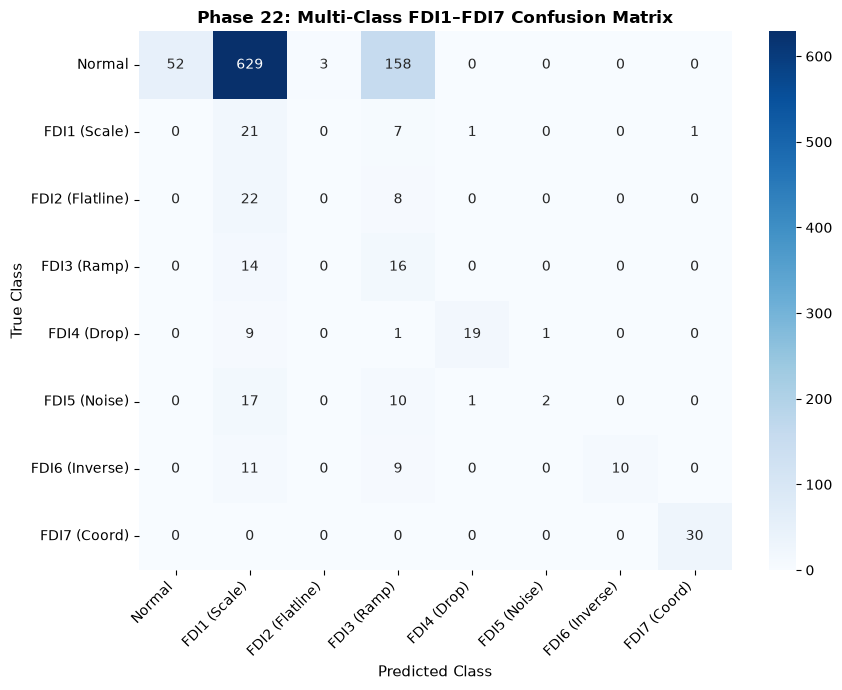

[COMPLETE] Phase 22 updated results and figures saved successfully.


In [2]:
# notebooks/20_phase22_multiclass_fdi.ipynb
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src.lstm_encoder import HybridCNNBiLSTMEncoder
from src.fdi_classifier import MultiClassTransferClassifier

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing Phase 22 Multi-Class FDI (FDI1-FDI7) on: {device}")

# -------------------------------------------------------------------------
# Step 1: Load Base Windows and Construct Controlled 8-Class Dataset
# -------------------------------------------------------------------------
data_path = Path('../data/processed_downstream/fdi_feeder_windows.npz')
assert data_path.exists(), f"Artifact missing at {data_path}"
data = np.load(data_path)

X_train_raw = data['X_train']  # (5011, 30, 12)
y_train_raw = data['y_train']  # binary
X_val_raw   = data['X_val']    # (1051, 30, 12)
y_val_raw   = data['y_val']
X_test_raw  = data['X_test']   # (1052, 30, 12)
y_test_raw  = data['y_test']

print(f"Input arrays loaded. X_train: {X_train_raw.shape}, X_test: {X_test_raw.shape}")

def inject_fdi_scenarios(X_arr, y_arr, seed=42):
    """
    Synthesizes exact Ahmad et al. FDI1-FDI7 signatures into attack windows
    while preserving clean normal windows as Class 0.
    """
    np.random.seed(seed)
    X_mod = X_arr.copy()
    y_multi = np.zeros(len(y_arr), dtype=np.int64)
    
    attack_indices = np.where(y_arr == 1)[0]
    num_attacks = len(attack_indices)
    
    # Evenly assign attack types 1 through 7 across attack windows
    assigned_types = np.array([(i % 7) + 1 for i in range(num_attacks)])
    np.random.shuffle(assigned_types)
    
    for idx, fdi_type in zip(attack_indices, assigned_types):
        y_multi[idx] = fdi_type
        win = X_mod[idx]  # (30, 12)
        T, C = win.shape
        start = np.random.randint(5, 15)
        duration = np.random.randint(8, 15)
        end = min(start + duration, T)
        
        target_ch = np.random.choice(C, size=np.random.randint(1, 4), replace=False)
        
        if fdi_type == 1:    # FDI1: Continuous Scaling
            alpha = np.random.choice([0.6, 0.75, 1.35, 1.5])
            win[start:end, target_ch] *= alpha
        elif fdi_type == 2:  # FDI2: Flatline / Sensor Freeze
            win[start:end, target_ch] = win[start, target_ch]
        elif fdi_type == 3:  # FDI3: Ramp Attack
            ramp = np.linspace(0, 0.5, end - start)[:, None]
            win[start:end, target_ch] += ramp
        elif fdi_type == 4:  # FDI4: Dropout / Curtailment
            win[start:end, target_ch] *= 0.05
        elif fdi_type == 5:  # FDI5: Gaussian Perturbation
            noise = np.random.normal(0, 0.25, size=(end - start, len(target_ch)))
            win[start:end, target_ch] += noise
        elif fdi_type == 6:  # FDI6: Power / Waveform Inversion
            win[start:end, target_ch] = np.clip(1.0 - win[start:end, target_ch], 0.0, 1.0)
        elif fdi_type == 7:  # FDI7: Coordinated Multi-Feeder Bias
            win[start:end, :] += 0.35
            
        X_mod[idx] = np.clip(win, 0.0, 1.0)
        
    return X_mod.astype(np.float32), y_multi

X_train_mc, y_train_mc = inject_fdi_scenarios(X_train_raw, y_train_raw, seed=42)
X_val_mc,   y_val_mc   = inject_fdi_scenarios(X_val_raw,   y_val_raw,   seed=101)
X_test_mc,  y_test_mc  = inject_fdi_scenarios(X_test_raw,  y_test_raw,  seed=202)

print("\n--- Multiclass Distribution (Train Split) ---")
for c in range(8):
    lbl = "Normal (Class 0)" if c == 0 else f"FDI{c}"
    cnt = np.sum(y_train_mc == c)
    print(f"  {lbl:20s}: {cnt:4d} windows ({cnt/len(y_train_mc)*100:.2f}%)")

# -------------------------------------------------------------------------
# Step 2: Balanced Sampler & Multi-Class Focal Loss Implementation
# -------------------------------------------------------------------------
# Stratified batching to counteract class 0 dominance
class_counts = np.bincount(y_train_mc, minlength=8)
class_sample_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
sample_weights = class_sample_weights[y_train_mc]

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train_mc), torch.from_numpy(y_train_mc)), 
    batch_size=64, 
    sampler=train_sampler,
    pin_memory=True
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val_mc), torch.from_numpy(y_val_mc)), 
    batch_size=64, 
    shuffle=False
)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test_mc), torch.from_numpy(y_test_mc)), 
    batch_size=64, 
    shuffle=False
)

class MultiClassFocalLoss(nn.Module):
    """
    Focal Loss with label smoothing to stabilize validation loss
    and prevent gradient explosion on minority attack classes.
    """
    def __init__(self, gamma: float = 2.0, label_smoothing: float = 0.1):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(
            logits, targets, reduction='none', label_smoothing=self.label_smoothing
        )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1.0 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

criterion = MultiClassFocalLoss(gamma=2.0, label_smoothing=0.1)

# -------------------------------------------------------------------------
# Step 3: Model Setup & Discriminative Fine-Tuning
# -------------------------------------------------------------------------
model = MultiClassTransferClassifier(
    in_channels=12,
    pretrained_channels=25,
    num_classes=8,
    cnn_hidden_dims=(64, 128),
    lstm_hidden_dim=128,
    lstm_layers=2,
    mlp_hidden_dim=64,
    dropout=0.3,
    freeze_backbone=False
).to(device)

ssl_ckpt = Path('../saved_models/ssl_cnn_bilstm.pth')
if ssl_ckpt.exists():
    state_dict = torch.load(ssl_ckpt, map_location=device, weights_only=True)
    model.encoder.load_state_dict(state_dict)
    print("[SUCCESS] Loaded Pretrained SSL Encoder Backbone")

# Discriminative learning rate: protect pretrained representations
optimizer = torch.optim.AdamW([
    {'params': model.channel_projector.parameters(), 'lr': 5e-4, 'weight_decay': 1e-4},
    {'params': model.encoder.parameters(),           'lr': 5e-5, 'weight_decay': 1e-4},
    {'params': model.mlp_head.parameters(),          'lr': 1e-3, 'weight_decay': 1e-4}
])

EPOCHS = 25
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_f1 = 0.0

print(f"\n--- Training Multi-Class FDI Classifier ({EPOCHS} Epochs) ---")
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        running_loss += loss.item() * len(xb)
        
    scheduler.step()
    train_loss = running_loss / len(train_loader.dataset)
    
    # Validation
    model.eval()
    val_loss, preds_val, targets_val = 0.0, [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * len(xb)
            preds_val.extend(torch.argmax(logits, dim=1).cpu().numpy())
            targets_val.extend(yb.cpu().numpy())
            
    val_loss /= len(val_loader.dataset)
    val_macro_f1 = f1_score(targets_val, preds_val, average='macro', zero_division=0)
    
    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        torch.save(model.state_dict(), '../saved_models/fdi_multiclass_best.pth')
        
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro-F1: {val_macro_f1*100:.2f}%")

# -------------------------------------------------------------------------
# Step 4: Holdout Evaluation & Export
# -------------------------------------------------------------------------
model.load_state_dict(torch.load('../saved_models/fdi_multiclass_best.pth', map_location=device, weights_only=True))
model.eval()

preds_test, targets_test = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds_test.extend(torch.argmax(logits, dim=1).cpu().numpy())
        targets_test.extend(yb.numpy())

class_names = ['Normal', 'FDI1 (Scale)', 'FDI2 (Flatline)', 'FDI3 (Ramp)', 
               'FDI4 (Drop)', 'FDI5 (Noise)', 'FDI6 (Inverse)', 'FDI7 (Coord)']

print("\n" + "="*70)
print("PHASE 22: MULTI-CLASS FDI1-FDI7 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(targets_test, preds_test, target_names=class_names, digits=4, zero_division=0))
print("="*70)

# Save metrics CSV
report_dict = classification_report(targets_test, preds_test, target_names=class_names, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report_dict).transpose()
results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)
df_report.to_csv(results_dir / 'phase22_multiclass_fdi_results.csv')

# Plot Confusion Matrix
cm = confusion_matrix(targets_test, preds_test)
fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Phase 22: Multi-Class FDI1–FDI7 Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=11)
plt.ylabel('True Class', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(fig_dir / 'phase22_multiclass_confusion_matrix.png', dpi=300)
plt.show()
print("[COMPLETE] Phase 22 updated results and figures saved successfully.")